## Fluvial Floods Model V2

- Fixed the scaler (was broken or not imported correctly)
- Removed insignificant features
- Added feature that takes into account past water level 

Imports

In [1]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib


Extract the data from the csv

In [2]:
water_level_df = pd.read_csv("fluvial_data/combined_2015_2026.csv")
weather_df = pd.read_csv("weather_data/weather_with_floods_2015_2026.csv")

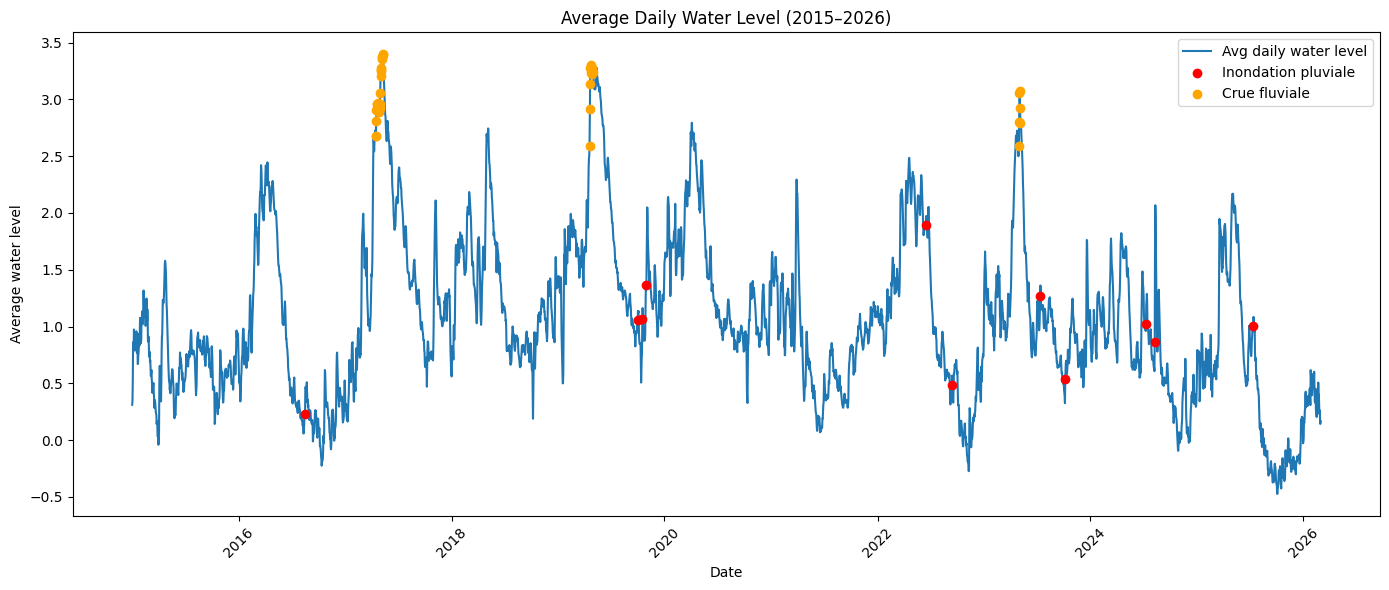

In [3]:
water_level_df['Formatted Date'] = pd.to_datetime(water_level_df['Date_d\'observation'])
water_level_df['Date'] = water_level_df['Formatted Date'].dt.date
daily_avg = water_level_df.groupby('Date')['SLEV(m)'].mean().reset_index()

# merge with weather dataset with water level info 
weather_df['Date'] = pd.to_datetime(weather_df['Date/Heure']).dt.date
merged = weather_df.merge(daily_avg, on='Date', how='left')

plt.figure(figsize=(14, 6))
plt.plot(daily_avg['Date'], daily_avg['SLEV(m)'], label='Avg daily water level')
plt.scatter(merged.loc[merged["Inondation pluviale"]==1, "Date"],
            merged.loc[merged["Inondation pluviale"]==1, "SLEV(m)"],
            color="red", label="Inondation pluviale", zorder=5)
plt.scatter(merged.loc[merged["Crue fluviale"]==1, "Date"],
            merged.loc[merged["Crue fluviale"]==1, "SLEV(m)"],
            color="orange", label="Crue fluviale", zorder=5)
plt.xlabel('Date')
plt.ylabel('Average water level')
plt.title('Average Daily Water Level (2015–2026)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
df = merged.copy()

# Make sure date is datetime and sorted
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Clean base columns
df["Rain"] = df["Précip. tot. (mm)"].fillna(0)
df["Temp"] = df["Temp moy.(°C)"]

# =========================
# SIMPLE WEATHER FEATURES
# =========================
df["Rain_1d"] = df["Rain"]
df["Rain_3d"] = df["Rain"].rolling(3, min_periods=1).sum()
df["Rain_5d"] = df["Rain"].rolling(5, min_periods=1).sum()
df["Rain_7d"] = df["Rain"].rolling(7, min_periods=1).sum()

df["Temp_3d_mean"] = df["Temp"].rolling(3, min_periods=1).mean()
df["Temp_5d_mean"] = df["Temp"].rolling(5, min_periods=1).mean()

# Positive temperature = rough snowmelt proxy
df["Temp_pos"] = df["Temp"].clip(lower=0)
df["Warm_3d_sum"] = df["Temp_pos"].rolling(3, min_periods=1).sum()
df["Warm_5d_sum"] = df["Temp_pos"].rolling(5, min_periods=1).sum()

# =========================
# SIMPLE WATER LEVEL FEATURES
# =========================
df["Water_Level"] = df["SLEV(m)"]
df["WL_3d_mean"] = df["SLEV(m)"].rolling(3, min_periods=1).mean()
df["WL_5d_mean"] = df["SLEV(m)"].rolling(5, min_periods=1).mean()

df["WL_change_1d"] = df["SLEV(m)"].diff(1)
df["WL_change_2d"] = df["SLEV(m)"].diff(2)
df["WL_change_3d"] = df["SLEV(m)"].diff(3)

# Rising only (sometimes easier to interpret)
df["WL_rise_1d"] = df["WL_change_1d"].clip(lower=0)
df["WL_rise_3d"] = df["WL_change_3d"].clip(lower=0)

# =========================
# INTERACTION FEATURES
# =========================
df["Rain_x_WL"] = df["Rain_3d"] * df["Water_Level"]
df["Warm_x_WL"] = df["Warm_3d_sum"] * df["Water_Level"]
df["Rain_x_WLrise"] = df["Rain_3d"] * df["WL_rise_3d"].fillna(0)

# =========================
# OPTIONAL SEASONAL FEATURES
# =========================
df["Month"] = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear

# Spring flag (many fluvial floods happen in spring)
df["Is_Spring"] = df["Month"].isin([3, 4, 5]).astype(int)

# Clean NaNs from diffs
feature_cols = [
    "Rain_1d", "Rain_3d", "Rain_5d", "Rain_7d",
    "Temp_3d_mean", "Temp_5d_mean",
    "Warm_3d_sum", "Warm_5d_sum",
    "Water_Level", "WL_3d_mean", "WL_5d_mean",
    "WL_change_1d", "WL_change_2d", "WL_change_3d",
    "WL_rise_1d", "WL_rise_3d",
    "Rain_x_WL", "Warm_x_WL", "Rain_x_WLrise",
    "Is_Spring"
]

df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

In [5]:
def plot_feature(df, col, flood_col="Crue fluviale", start=None, end=None):
    plot_df = df.copy()

    if start is not None:
        plot_df = plot_df[plot_df["Date"] >= pd.to_datetime(start)]
    if end is not None:
        plot_df = plot_df[plot_df["Date"] <= pd.to_datetime(end)]

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["Date"], plot_df[col], label=col)

    flood_days = plot_df[plot_df[flood_col] == 1]
    plt.scatter(
        flood_days["Date"],
        flood_days[col],
        color="orange",
        label="Flood days",
        zorder=5
    )

    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

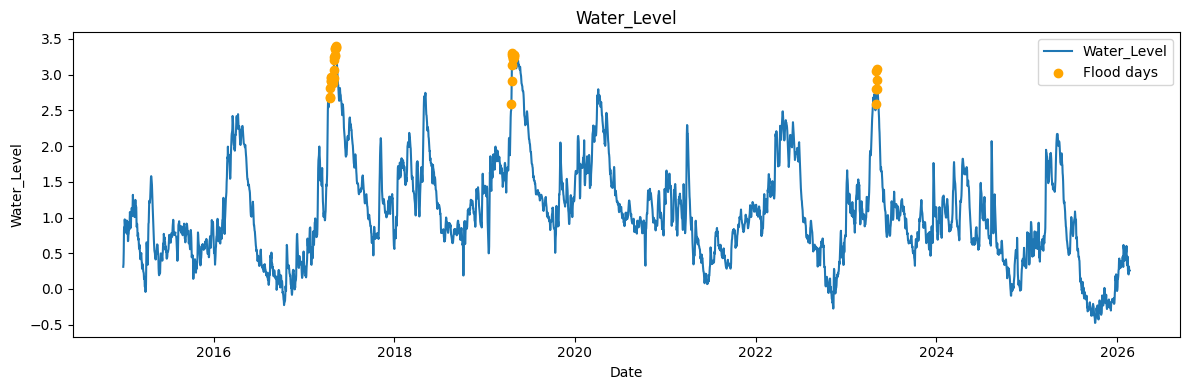

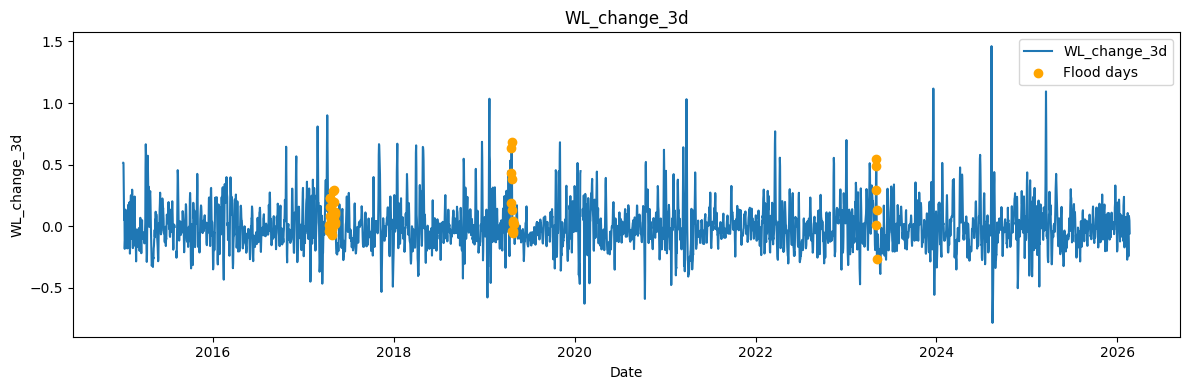

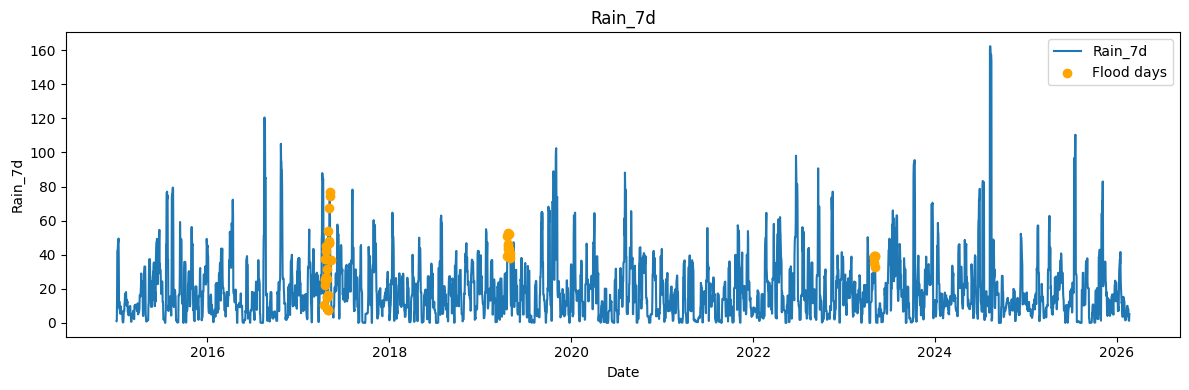

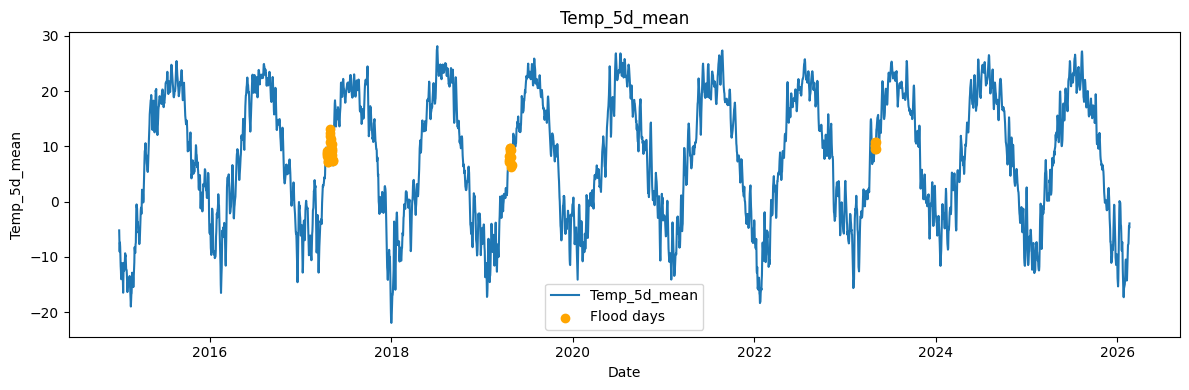

In [6]:
features_kept = [
    "Water_Level",
    "WL_change_3d",
    "Rain_7d",
    "Temp_5d_mean"
]
for f in features_kept:
    plot_feature(df, f)

In [7]:
# Effect size
def effect_size(series, label):
    return (series[label == 1].mean() - series.mean()) / series.std()

effect_sizes = {
    col: effect_size(df[col], df["Crue fluviale"])
    for col in features_kept
}

print("Effect sizes:")
for k, v in effect_sizes.items():
    print(f"{k}: {v:.3f}")

# Convert to weights & scale
total = sum(abs(v) for v in effect_sizes.values())

weights = {
    k: abs(v) / total
    for k, v in effect_sizes.items()
}

print("\nRelative weights:")
for k, v in weights.items():
    print(f"{k}: {v:.3f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_kept])

Effect sizes:
Water_Level: 2.809
WL_change_3d: 0.709
Rain_7d: 0.985
Temp_5d_mean: 0.108

Relative weights:
Water_Level: 0.609
WL_change_3d: 0.154
Rain_7d: 0.214
Temp_5d_mean: 0.023


In [8]:
joblib.dump(scaler, "fluvial_scaler_V2.pkl")

['fluvial_scaler_V2.pkl']

In [9]:
import pandas as pd
import numpy as np
import joblib

# Load the saved scaler
scaler_reloaded = joblib.load("fluvial_scaler_V2.pkl")

# Create a dummy "New Observation" with raw values
test_data = pd.DataFrame([{
    "Water_Level": 2.8,       # Slightly above average
    "WL_change_3d": 0.05, 
    "Rain_7d": 15.0,         # High rain
    "Temp_5d_mean": 12.0
}])

# Apply the reloaded scaler
X_test_scaled = scaler_reloaded.transform(test_data)

print("--- Scaler Test Results ---")
print(f"Mean learned by scaler for Water_Level: {scaler_reloaded.mean_[0]:.4f}")
print(f"Scale (Std) learned for Water_Level: {scaler_reloaded.scale_[0]:.4f}")
print("\nScaled values for production use:")
for i, col in enumerate(test_data.columns):
    print(f"{col}: {X_test_scaled[0, i]:.4f}")

# Integrity Check: Does scaling then un-scaling return the original values?
reversed_data = scaler_reloaded.inverse_transform(X_test_scaled)
if np.allclose(test_data.values, reversed_data):
    print("\n✅ Success: Scaler integrity verified. Inverse transform matches input.")
else:
    print("\n❌ Error: Scaler failed integrity check.")

--- Scaler Test Results ---
Mean learned by scaler for Water_Level: 1.0720
Scale (Std) learned for Water_Level: 0.7052

Scaled values for production use:
Water_Level: 2.4502
WL_change_3d: 0.2764
Rain_7d: -0.2584
Temp_5d_mean: 0.3691

✅ Success: Scaler integrity verified. Inverse transform matches input.


In [10]:
gamma = 2
target_prob = 0.9


# Calculate intercept
raw_scores = np.zeros(len(df))
for i, col in enumerate(features_kept):
    raw_scores += weights[col] * X_scaled[:, i]
raw_scores_gamma = gamma * raw_scores

flood_mask = df["Crue fluviale"] == 1
max_score = raw_scores_gamma[flood_mask].max()
intercept = np.log(target_prob / (1 - target_prob)) - max_score

print(f"Intercept: {intercept}")

def predict_flood_probability(raw_df, features, weights, scaler, intercept, gamma=2):
    # Important: Always scale the raw data using the reloaded scaler first
    X_scaled_new = scaler.transform(raw_df[features])
    
    # Calculate weighted sum
    score = np.zeros(len(raw_df))
    for i, col in enumerate(features):
        score += weights[col] * X_scaled_new[:, i]
    
    # Apply gamma, intercept, and Sigmoid function
    final_score = (gamma * score) + intercept
    probability = 1 / (1 + np.exp(-final_score))
    
    return probability


prob = predict_flood_probability(test_data, features_kept, weights, scaler_reloaded, intercept, gamma)

print(f"\n--- Prediction for New Data ---")
print(f"Input Water Level: {test_data['Water_Level'].values[0]}")
print(f"Calculated Flood Probability: {prob[0]:.2%}")

Intercept: -3.3160865607447074

--- Prediction for New Data ---
Input Water Level: 2.8
Calculated Flood Probability: 41.60%


In [13]:
# Calculate the raw scores for the whole dataset

# Using the X_scaled matrix we created during the scaling step
raw_scores_all = np.zeros(len(df))
for i, col in enumerate(features_kept):
    raw_scores_all += weights[col] * X_scaled[:, i]

# Apply the logistic transformation (Gamma + Intercept)
# This converts the linear score into a 0 to 1 probability
final_scores_all = (gamma * raw_scores_all) + intercept
df["Prob_Fluvial"] = 1 / (1 + np.exp(-final_scores_all))

print("--- Top 200 Highest Flood Risk Events ---")
print(df[["Date", "Prob_Fluvial", "Water_Level"]].nlargest(200, 'Prob_Fluvial'))

--- Top 200 Highest Flood Risk Events ---
           Date  Prob_Fluvial  Water_Level
3510 2024-08-11      0.985422     2.067917
3511 2024-08-12      0.966978     1.979583
3509 2024-08-10      0.943564     1.675000
827  2017-04-07      0.902245     2.497917
1572 2019-04-22      0.900000     3.274583
...         ...           ...          ...
1929 2020-04-13      0.356057     2.550000
3030 2023-04-19      0.356014     2.561667
1926 2020-04-10      0.352800     2.706667
914  2017-07-03      0.350500     2.367917
1840 2020-01-15      0.348039     2.090000

[200 rows x 3 columns]
